`conda activate r_python`

In [ ]:
# import the functions to plot the respective functions
source('scripts/plotSingleTaskRNA.R');


Attaching package: ‘Hmisc’


The following objects are masked from ‘package:base’:

    format.pval, units



Attaching package: ‘plyr’


The following objects are masked from ‘package:Hmisc’:

    is.discrete, summarize



Attaching package: ‘dplyr’


The following objects are masked from ‘package:plyr’:

    arrange, count, desc, failwith, id, mutate, rename, summarise,
    summarize


The following objects are masked from ‘package:Hmisc’:

    src, summarize


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2


Attaching package: ‘cowplot’


The following object is masked from ‘package:ggimage’:

    theme_nothing




In [ ]:
df <- read.table('data/metrics_multi_integration_dmg_atlas.csv', 
                 sep=',', header=T) %>%
                `row.names<-`(c('MultiVIModality_hvg_embed',
                                'MultiVISampleID_hvg_embed',
                                'GlueModality_hvg_embed',
                                'GlueModalityBatch_hvg_embed',
                                'MultigrateModality_hvg_embed',
                                'MultigrateModalityBatch_hvg_embed')) %>%
                select(-X)
df

,NMI_cluster.label,ARI_cluster.label,ASW_label,ASW_label.batch,PCR_batch,cell_cycle_conservation,isolated_label_F1,isolated_label_silhouette,graph_conn,kBET,iLISI,cLISI,hvg_overlap,trajectory
,<lgl>,<lgl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
MultiVIModality_hvg_embed,NA,NA,0.5087607,0.8045302,NA,NA,NA,0.5272362,0.8022975,NA,NA,NA,NA,NA
MultiVISampleID_hvg_embed,NA,NA,0.5321940,0.7901926,NA,NA,NA,0.5787809,0.8444780,NA,NA,NA,NA,NA
GlueModality_hvg_embed,NA,NA,0.5216878,0.8420881,NA,NA,NA,0.5849631,0.8464302,NA,NA,NA,NA,NA
GlueModalityBatch_hvg_embed,NA,NA,0.5288567,0.8417591,NA,NA,NA,0.5921233,0.8374728,NA,NA,NA,NA,NA
MultigrateModality_hvg_embed,NA,NA,0.5154411,0.7594653,NA,NA,NA,0.4897349,0.7933439,NA,NA,NA,NA,NA
MultigrateModalityBatch_hvg_embed,NA,NA,0.5060080,0.8045710,NA,NA,NA,0.4738079,0.8014677,NA,NA,NA,NA,NA


In [ ]:
write.table(df, 'data/metrics_multi_integration_dmg_atlas_modified.csv', row.names = TRUE,
           col.names = TRUE, quote = FALSE, sep = ',')

In [ ]:
dim(df)

[1]  6 14

In [ ]:
rownames(df) <- str_replace(rownames(df), "\\+", 'and')
rownames(df) <- str_replace(rownames(df), "\\+", 'and')
rownames(df) <- str_replace(rownames(df), "\\+", 'and')

In [ ]:
df <- df[grepl('Roska', rownames(df)) == FALSE,]
df <- df[grepl('_E', rownames(df)),]
# df <- df[grepl('_L', rownames(df)),]

In [ ]:
dim(df)

[1]  0 14

In [ ]:
metrics_path_all = 'data/metrics_multi_integration_dmg_atlas_modified.csv'

In [ ]:
csv_metrics_path <- metrics_path_all

In [ ]:
outdir = 'figures'
print(outdir)
weight_batch = 0.4
metrics_tab_lab <- read.table(csv_metrics_path, sep = ",", header = TRUE) %>% 
                    tibble::rownames_to_column('X')

[1] "figures"


In [ ]:
metrics_tab_lab

X,NMI_cluster.label,ARI_cluster.label,ASW_label,ASW_label.batch,PCR_batch,cell_cycle_conservation,isolated_label_F1,isolated_label_silhouette,graph_conn,kBET,iLISI,cLISI,hvg_overlap,trajectory
<chr>,<lgl>,<lgl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
MultiVIModality_hvg_embed,NA,NA,0.5087607,0.8045302,NA,NA,NA,0.5272362,0.8022975,NA,NA,NA,NA,NA
MultiVISampleID_hvg_embed,NA,NA,0.5321940,0.7901926,NA,NA,NA,0.5787809,0.8444780,NA,NA,NA,NA,NA
GlueModality_hvg_embed,NA,NA,0.5216878,0.8420881,NA,NA,NA,0.5849631,0.8464302,NA,NA,NA,NA,NA
GlueModalityBatch_hvg_embed,NA,NA,0.5288567,0.8417591,NA,NA,NA,0.5921233,0.8374728,NA,NA,NA,NA,NA
MultigrateModality_hvg_embed,NA,NA,0.5154411,0.7594653,NA,NA,NA,0.4897349,0.7933439,NA,NA,NA,NA,NA
MultigrateModalityBatch_hvg_embed,NA,NA,0.5060080,0.8045710,NA,NA,NA,0.4738079,0.8014677,NA,NA,NA,NA,NA


In [ ]:
metrics_tab_lab$X <- str_replace(metrics_tab_lab$X, "\\+", 'and')
metrics_tab_lab$X <- str_replace(metrics_tab_lab$X, "\\+", 'and')
metrics_tab_lab$X <- str_replace(metrics_tab_lab$X, "\\+", 'and')

# print(metrics_tab_lab)
# get metrics names from columns
metrics <- colnames(metrics_tab_lab)[-1]
metrics <- gsub("\\.", "/", metrics)
metrics <- gsub("_", " ", metrics)
# print(metrics)
metrics <- plyr::mapvalues(metrics, from = c("ASW label", "ASW label/batch", "cell cycle conservation", "hvg overlap", "trajectory", "graph conn", "iLISI", "cLISI"), 
                         to = c("Cell type ASW", "Batch ASW", "CC conservation", "HVG conservation", "trajectory conservation", "graph connectivity", "graph iLISI", "graph cLISI"))
print(metrics)
# stopifnot(FALSE)

# metrics names as they are supposed to be ordered
group_batch <- c("PCR batch", "Batch ASW", "graph iLISI", "graph connectivity", "kBET")
group_bio <- c("NMI cluster/label", "ARI cluster/label", "Cell type ASW", 
             "isolated label F1", "isolated label silhouette", "graph cLISI", "CC conservation", "HVG conservation", "trajectory conservation")
# set original values of number of metrics
n_metrics_batch_original <- sum(group_batch %in% metrics)
n_metrics_bio_original <- sum(group_bio %in% metrics)

# order metrics present in the table
matching.order <- match(c(group_batch, group_bio), metrics)
metrics.ord <- metrics[matching.order[!is.na(matching.order)]]

# get methods info from rownames
methods_info_full  <- as.character(metrics_tab_lab[,1])

# in case methods names start with /
if(substring(methods_info_full[1], 1, 1) == "/"){
methods_info_full <- sub("/", "", methods_info_full)
}

# Remove trvae full
ind.trvae_full <- grep("trvae_full", methods_info_full)
if(length(ind.trvae_full) > 0){
methods_info_full <- methods_info_full[-ind.trvae_full]
metrics_tab_lab <- metrics_tab_lab[-ind.trvae_full,]
}

# data scenarios to be saved in file name
data.scenarios <- unique(unlist(sapply(str_split(methods_info_full, "/"), function(x) x[2])))

print(data.scenarios)


 [1] "NMI cluster/label"         "ARI cluster/label"        
 [3] "Cell type ASW"             "Batch ASW"                
 [5] "PCR batch"                 "CC conservation"          
 [7] "isolated label F1"         "isolated label silhouette"
 [9] "graph connectivity"        "kBET"                     
[11] "graph iLISI"               "graph cLISI"              
[13] "HVG conservation"          "trajectory conservation"  
[1] NA


In [ ]:
methods_info_full

[1] "MultiVIModality_hvg_embed"         "MultiVISampleID_hvg_embed"        
[3] "GlueModality_hvg_embed"            "GlueModalityBatch_hvg_embed"      
[5] "MultigrateModality_hvg_embed"      "MultigrateModalityBatch_hvg_embed"

In [ ]:
###### Plot one figure for each data task

methods_info <- methods_info_full
metrics_tab_sub <- metrics_tab_lab

In [ ]:
metrics_tab_sub

X,NMI_cluster.label,ARI_cluster.label,ASW_label,ASW_label.batch,PCR_batch,cell_cycle_conservation,isolated_label_F1,isolated_label_silhouette,graph_conn,kBET,iLISI,cLISI,hvg_overlap,trajectory
<chr>,<lgl>,<lgl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
MultiVIModality_hvg_embed,NA,NA,0.5087607,0.8045302,NA,NA,NA,0.5272362,0.8022975,NA,NA,NA,NA,NA
MultiVISampleID_hvg_embed,NA,NA,0.5321940,0.7901926,NA,NA,NA,0.5787809,0.8444780,NA,NA,NA,NA,NA
GlueModality_hvg_embed,NA,NA,0.5216878,0.8420881,NA,NA,NA,0.5849631,0.8464302,NA,NA,NA,NA,NA
GlueModalityBatch_hvg_embed,NA,NA,0.5288567,0.8417591,NA,NA,NA,0.5921233,0.8374728,NA,NA,NA,NA,NA
MultigrateModality_hvg_embed,NA,NA,0.5154411,0.7594653,NA,NA,NA,0.4897349,0.7933439,NA,NA,NA,NA,NA
MultigrateModalityBatch_hvg_embed,NA,NA,0.5060080,0.8045710,NA,NA,NA,0.4738079,0.8014677,NA,NA,NA,NA,NA


In [ ]:
print(methods_info)    
# info on scaling data
scaling <- rep(F, length(methods_info)) # sapply(str_split(methods_info, "/"), function(x) x[3])

[1] "MultiVIModality_hvg_embed"         "MultiVISampleID_hvg_embed"        
[3] "GlueModality_hvg_embed"            "GlueModalityBatch_hvg_embed"      
[5] "MultigrateModality_hvg_embed"      "MultigrateModalityBatch_hvg_embed"


In [ ]:

# info on HVG selection
hvg <- sapply(str_split(methods_info, "_"), function(x) x[2])
hvg <- plyr::mapvalues(hvg, from = c("hvg", "full_feature"), to = c("HVG", "FULL"))

print(hvg)

methods <- sapply(str_split(methods_info, "_"), function(x) x[1])

methods_name <- sapply(str_split(methods, "_"), function(x) x[1])
methods_name <- capitalize(methods_name)
methods_name <- plyr::mapvalues(methods_name, 
                                from = c("Multivi", "Scvi", "Seurat", "Seuratrpca", "Mnn", "Bbknn", "Trvae", "Scvi", "Liger", "Combat", "Saucie", "Fastmnn", "Desc", "Scanvi", "Scgen"), 
                                to = c("MultiVI", "scVI", "Seurat v3 CCA", "Seurat v3 RPCA", "MNN", "BBKNN", "trVAE", "scVI", "LIGER", "ComBat", "SAUCIE", "fastMNN", "DESC", "scANVI*", "scGen*"))


method_groups <- sapply(str_split(methods_info, "_"), function(x) x[3])
method_groups <- plyr::mapvalues(method_groups, 
                                  from = c("knn", "embed", "full"), 
                                  to = c("graph", "embed", "gene"))



##### Create dataframe 
metrics_tab <- as.data.frame(metrics_tab_sub[, -1])
metrics_tab[metrics_tab == ""] <- NA
colnames(metrics_tab) <- metrics

#add Methods column
metrics_tab <- add_column(metrics_tab, "Method" = methods_name, .before = 1)

# reorder columns by metrics
col.ordered <- c("Method", metrics.ord)
metrics_tab <- metrics_tab[, col.ordered]

## Remove columns that are full NAs
na.col <- apply(metrics_tab, 2, function(x) sum(is.na(x)) == nrow(metrics_tab))
# redefine numbers of metrics per group
print('metrics columns')
print(colnames(metrics_tab))
if(sum(colnames(metrics_tab)[na.col] %in%  group_batch) > 0){
  n_metrics_batch <- n_metrics_batch_original - sum(colnames(metrics_tab)[na.col] %in%  group_batch)
} else {
  n_metrics_batch <- n_metrics_batch_original
}

if(sum(colnames(metrics_tab)[na.col] %in% group_bio) > 0){
  n_metrics_bio <- n_metrics_bio_original - sum(colnames(metrics_tab)[na.col] %in% group_bio)
} else{
  n_metrics_bio <- n_metrics_bio_original
}
  
metrics_tab <- metrics_tab[, !na.col]

print(dim(metrics_tab))

## Scores should be already scaled [0,1] - however, we aim to compute the scores based on the min-max scaled metrics
print('here...')
print(rownames(metrics_tab))
print(dim(metrics_tab))
scaled_metrics_tab <- as.matrix(metrics_tab[, -1])
print(dim(scaled_metrics_tab))

use_scale_minmax <- F
if(use_scale_minmax)
   scaled_metrics_tab <- apply(scaled_metrics_tab, 2, function(x) scale_minmax(x))

# calculate average score by group and overall
print(scaled_metrics_tab)
print(n_metrics_batch)
print(scaled_metrics_tab[, 1:n_metrics_batch])
score_group_batch <- rowMeans(scaled_metrics_tab[, 1:n_metrics_batch], na.rm = T)
score_group_bio <- rowMeans(scaled_metrics_tab[, (1+n_metrics_batch):ncol(scaled_metrics_tab)], 
                          na.rm = T)

score_all <- (weight_batch*score_group_batch + (1-weight_batch)*score_group_bio)

metrics_tab <- add_column(metrics_tab, "Overall Score" = score_all, .after = "Method")
metrics_tab <- add_column(metrics_tab, "Batch Correction" = score_group_batch, .after = "Overall Score")
metrics_tab <- add_column(metrics_tab, "Bio conservation" = score_group_bio, .after = 3+n_metrics_batch)

metrics_tab <- add_column(metrics_tab, "Output" = method_groups, .after = "Method")
metrics_tab <- add_column(metrics_tab, "Features" = hvg, .after = "Output")
metrics_tab <- add_column(metrics_tab, "Scaling" = scaling, .after = "Features")

# order methods by the overall score
metrics_tab <- metrics_tab[order(metrics_tab$`Overall Score`,  decreasing = T), ]
write.csv(metrics_tab, file = paste0(outdir, "/", "multi_integration_dmg_atlas_summary_scores.csv"), quote = F)


# Delete rows that are empty
rowsNA <- which(is.na(metrics_tab$`Overall Score`))
if(length(rowsNA) >0){
  metrics_tab <- metrics_tab[-rowsNA, ]
}


# Defining column_info, row_info and palettes
row_info <- data.frame(id = metrics_tab$Method)

column_info <- data.frame(id = colnames(metrics_tab),
                          group = c("Text", "Image", "Text", "Text", "Score overall", 
                                    rep("Removal of batch effects", (1 + n_metrics_batch)),
                                    rep("Cell type label variance", (1 + n_metrics_bio))), 
                          geom = c("text", "image", "text", "text", "bar", "bar", 
                                    rep("circle", n_metrics_batch), "bar", rep("circle", n_metrics_bio)),
                          width = c(8,2.5,2,1.5,2,2, rep(1,n_metrics_batch), 2, rep(1,n_metrics_bio)),
                          overlay = F)

# defining colors palette
palettes <- list("Score overall" = "YlGnBu",
                  "Removal of batch effects" = "BuPu",
                  "Cell type label variance" = "RdPu")



The following `from` values were not present in `x`: full_feature



[1] "HVG" "HVG" "HVG" "HVG" "HVG" "HVG"


The following `from` values were not present in `x`: Multivi, Scvi, Seurat, Seuratrpca, Mnn, Bbknn, Trvae, Scvi, Liger, Combat, Saucie, Fastmnn, Desc, Scanvi, Scgen

The following `from` values were not present in `x`: knn, full



[1] "metrics columns"
 [1] "Method"                    "PCR batch"                
 [3] "Batch ASW"                 "graph iLISI"              
 [5] "graph connectivity"        "kBET"                     
 [7] "NMI cluster/label"         "ARI cluster/label"        
 [9] "Cell type ASW"             "isolated label F1"        
[11] "isolated label silhouette" "graph cLISI"              
[13] "CC conservation"           "HVG conservation"         
[15] "trajectory conservation"  
[1] 6 5
[1] "here..."
[1] "1" "2" "3" "4" "5" "6"
[1] 6 5
[1] 6 4
     Batch ASW graph connectivity Cell type ASW isolated label silhouette
[1,] 0.8045302          0.8022975     0.5087607                 0.5272362
[2,] 0.7901926          0.8444780     0.5321940                 0.5787809
[3,] 0.8420881          0.8464302     0.5216878                 0.5849631
[4,] 0.8417591          0.8374728     0.5288567                 0.5921233
[5,] 0.7594653          0.7933439     0.5154411                 0.4897349
[6,] 0.8

In [ ]:
metrics_tab

,Method,Output,Features,Scaling,Overall Score,Batch Correction,Batch ASW,graph connectivity,Bio conservation,Cell type ASW,isolated label silhouette
,<chr>,<chr>,<chr>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,GlueModalityBatch,embed,HVG,FALSE,0.6721404,0.8396160,0.8417591,0.8374728,0.5604900,0.5288567,0.5921233
3,GlueModality,embed,HVG,FALSE,0.6696989,0.8442592,0.8420881,0.8464302,0.5533254,0.5216878,0.5849631
2,MultiVISampleID,embed,HVG,FALSE,0.6602266,0.8173353,0.7901926,0.8444780,0.5554874,0.5321940,0.5787809
1,MultiVIModality,embed,HVG,FALSE,0.6321646,0.8034139,0.8045302,0.8022975,0.5179985,0.5087607,0.5272362
6,MultigrateModalityBatch,embed,HVG,FALSE,0.6151525,0.8030194,0.8045710,0.8014677,0.4899079,0.5060080,0.4738079
5,MultigrateModality,embed,HVG,FALSE,0.6121146,0.7764046,0.7594653,0.7933439,0.5025880,0.5154411,0.4897349


In [ ]:
print('attempting to generate plot at')
g <- scIB_knit_table(data = metrics_tab, column_info = column_info, 
                     row_info = row_info, 
                     palettes = palettes, 
                     usability = F)  

[1] "attempting to generate plot at"


The following `from` values were not present in `x`: scaled, unscaled

The following `from` values were not present in `x`: graph, gene

Warning message:
“`data_frame()` was deprecated in tibble 1.1.0.
ℹ Please use `tibble()` instead.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


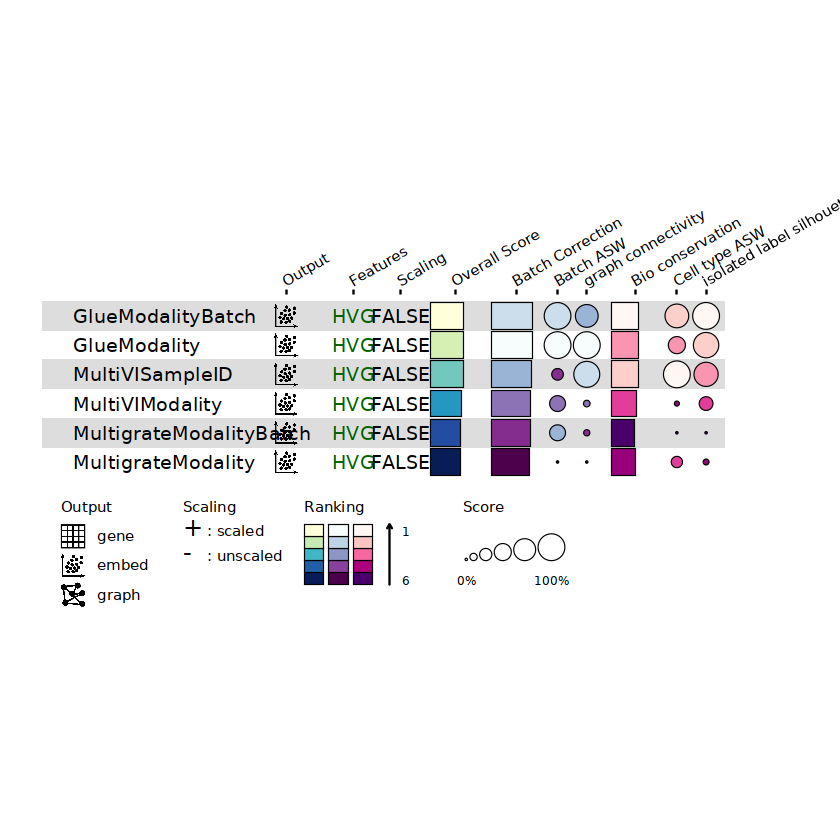

In [ ]:
g

In [ ]:
ggsave(paste0(outdir, "/summary_metrics.pdf"), g, device = cairo_pdf, width = 297, height = 420, units = "mm")